# OmniParser v2 demo

Pipeline:
1. **YOLO** (`weights/icon_detect/model.pt`) — detects UI element bounding boxes
2. **Florence-2** — processor pulled from HuggingFace hub (`microsoft/Florence-2-base`), weights from `weights/icon_caption_florence/` — captions each crop
3. Draws annotated boxes on the image and prints results

In [3]:
from pathlib import Path
import numpy as np
import torch
import cv2
from PIL import Image, ImageDraw, ImageFont
from torchvision.transforms import ToPILImage
from ultralytics import YOLO
from transformers import AutoModelForCausalLM, AutoProcessor
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()
WEIGHTS    = REPO_ROOT / "weights"
YOLO_PATH  = WEIGHTS / "icon_detect" / "model.pt"
# model weights only — NO processor files here, that's intentional
CAPTION_PATH = WEIGHTS / "icon_caption_florence"

DEVICE = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
DTYPE = torch.float16 if DEVICE != "cpu" else torch.float32
print(f"device={DEVICE}  dtype={DTYPE}")
print(f"YOLO   : {YOLO_PATH}")
print(f"Caption: {CAPTION_PATH}")

device=mps  dtype=torch.float16
YOLO   : /Users/computer/dev/ai/cua/weights/icon_detect/model.pt
Caption: /Users/computer/dev/ai/cua/weights/icon_caption_florence


In [4]:
yolo = YOLO(str(YOLO_PATH))

# Processor comes from the HuggingFace hub (Florence-2-base)
# because the local weights folder only contains model weights, not tokenizer/processor files
processor = AutoProcessor.from_pretrained(
    "microsoft/Florence-2-base", trust_remote_code=True
)

# Model weights loaded from the local fine-tuned checkpoint
caption_model = AutoModelForCausalLM.from_pretrained(
    str(CAPTION_PATH),
    torch_dtype=DTYPE,
    trust_remote_code=True,
).to(DEVICE)
caption_model.eval()
print("models ready")

preprocessor_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

processing_florence2.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-base:
- processing_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_config.json:   0%|          | 0.00/34.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

configuration_florence2.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-base:
- configuration_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_florence2.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-base-ft:
- modeling_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


models ready


In [9]:
@torch.inference_mode()
def caption_batch(crops: list[Image.Image], prompt: str = "<CAPTION>", batch_size: int = 64) -> list[str]:
    """Caption a list of PIL crops in batches using Florence-2."""
    captions = []
    for i in range(0, len(crops), batch_size):
        batch = crops[i : i + batch_size]
        inputs = processor(
            images=batch,
            text=[prompt] * len(batch),
            return_tensors="pt",
            do_resize=False,
        )
        if DEVICE in {"cuda", "mps"}:
            inputs = inputs.to(device=DEVICE, dtype=DTYPE)
        generated = caption_model.generate(
            input_ids=inputs["input_ids"],
            pixel_values=inputs["pixel_values"],
            max_new_tokens=20,
            num_beams=1,
            do_sample=False,
            early_stopping=False,
        )
        texts = processor.batch_decode(generated, skip_special_tokens=True)
        captions.extend([t.strip() for t in texts])
    return captions


_paddle_reader = None


def _get_paddle_reader():
    """Lazy-initialise a single PaddleOCR instance (it's expensive to build)."""
    global _paddle_reader
    if _paddle_reader is None:
        from paddleocr import PaddleOCR
        kwargs = {"lang": "en"}
        # API differs between PaddleOCR 2.x and 3.x — try 3.x args, fall back
        try:
            _paddle_reader = PaddleOCR(
                device=("gpu" if DEVICE == "cuda" else "cpu"),
                use_textline_orientation=True,
                **kwargs,
            )
        except (TypeError, ValueError):
            _paddle_reader = PaddleOCR(use_angle_cls=True, **kwargs)
    return _paddle_reader


def _parse_paddle_result(results) -> list[tuple[list, str, float]]:
    """Normalise PaddleOCR 2.x and 3.x result shapes to [(quad, text, conf), ...]."""
    items: list[tuple[list, str, float]] = []
    if not results:
        return items
    page = results[0]

    # 3.x returns a dict-like object with rec_texts / rec_scores / rec_polys
    if isinstance(page, dict) or hasattr(page, "get"):
        polys  = page.get("rec_polys")  or page.get("dt_polys")  or []
        texts  = page.get("rec_texts")  or []
        scores = page.get("rec_scores") or []
        for quad, text, conf in zip(polys, texts, scores):
            items.append((list(quad), str(text), float(conf)))
        return items

    # 2.x returns [[quad, (text, conf)], ...]
    for entry in page or []:
        quad, (text, conf) = entry[0], entry[1]
        items.append((quad, str(text), float(conf)))
    return items


def run_ocr(image: Image.Image, text_threshold: float = 0.8
            ) -> tuple[list[str], list[list[float]]]:
    """Return (texts, xyxy_boxes_normalised) using PaddleOCR."""
    reader = _get_paddle_reader()
    w, h = image.size
    try:
        results = reader.predict(np.array(image))  # 3.x
    except AttributeError:
        results = reader.ocr(np.array(image), cls=True)  # 2.x

    texts, bboxes = [], []
    for quad, text, conf in _parse_paddle_result(results):
        if conf < text_threshold:
            continue
        xs = [p[0] for p in quad]
        ys = [p[1] for p in quad]
        x0, y0, x1, y1 = min(xs), min(ys), max(xs), max(ys)
        if (x1 - x0) * (y1 - y0) <= 0:
            continue
        texts.append(text)
        bboxes.append([x0 / w, y0 / h, x1 / w, y1 / h])
    return texts, bboxes


def parse_image(
    image_path: str | Path,
    bbox_threshold: float = 0.05,
    iou_threshold: float = 0.7,
    imgsz: int | None = None,
    use_ocr: bool = True,
    crop_size: int = 64,
):
    """Detect + caption all UI elements. Returns (annotated_image, detections).

    Parameters
    ----------
    bbox_threshold : YOLO confidence threshold (lower → more boxes)
    iou_threshold  : NMS IoU threshold (lower → fewer overlapping boxes)
    imgsz          : YOLO inference resolution; None = native image size
    use_ocr        : overlay EasyOCR text regions alongside icon detections
    crop_size      : pixel size crops are resized to before captioning
    """
    image = Image.open(image_path).convert("RGB")
    w, h = image.size
    image_np = np.asarray(image)

    predict_kwargs = dict(conf=bbox_threshold, iou=iou_threshold, verbose=False)
    if imgsz is not None:
        predict_kwargs["imgsz"] = imgsz

    results = yolo.predict(image, **predict_kwargs)[0]
    boxes  = results.boxes.xyxy.cpu().numpy()
    scores = results.boxes.conf.cpu().numpy()

    crops = []
    for x0, y0, x1, y1 in boxes:
        crop = image_np[int(y0):int(y1), int(x0):int(x1)]
        crop = cv2.resize(crop, (crop_size, crop_size))
        crops.append(ToPILImage()(crop))

    captions = caption_batch(crops) if crops else []

    detections = [
        {
            "id": idx,
            "type": "icon",
            "box": (float(x0), float(y0), float(x1), float(y1)),
            "score": float(score),
            "label": label,
        }
        for idx, ((x0, y0, x1, y1), score, label)
        in enumerate(zip(boxes, scores, captions))
    ]

    if use_ocr:
        ocr_texts, ocr_norm_boxes = run_ocr(image)
        start = len(detections)
        for i, (text, nb) in enumerate(zip(ocr_texts, ocr_norm_boxes)):
            detections.append({
                "id": start + i,
                "type": "text",
                "box": (nb[0]*w, nb[1]*h, nb[2]*w, nb[3]*h),
                "score": 1.0,
                "label": text,
            })

    annotated = draw_detections(image, detections)
    return annotated, detections


def draw_detections(image: Image.Image, detections: list[dict]) -> Image.Image:
    annotated = image.copy()
    draw = ImageDraw.Draw(annotated)
    try:
        font = ImageFont.truetype("Arial.ttf", 13)
    except OSError:
        font = ImageFont.load_default()

    COLORS = {"icon": "#ff3366", "text": "#3399ff"}
    for det in detections:
        x0, y0, x1, y1 = det["box"]
        color = COLORS.get(det.get("type", "icon"), "#ff3366")
        label = f"{det['id']}: {det['label']}"
        draw.rectangle([x0, y0, x1, y1], outline=color, width=2)
        tb = draw.textbbox((x0, y0), label, font=font)
        draw.rectangle([tb[0], tb[1] - 2, tb[2] + 4, tb[3] + 2], fill=color)
        draw.text((tb[0] + 2, tb[1]), label, fill="white", font=font)
    return annotated

/var/folders/ny/321h18td74qbgkzyl41nt8740000gn/T/ipykernel_33101/1145601148.py:89: RuntimeWarning: overflow encountered in scalar multiply
  if (x1 - x0) * (y1 - y0) <= 0:


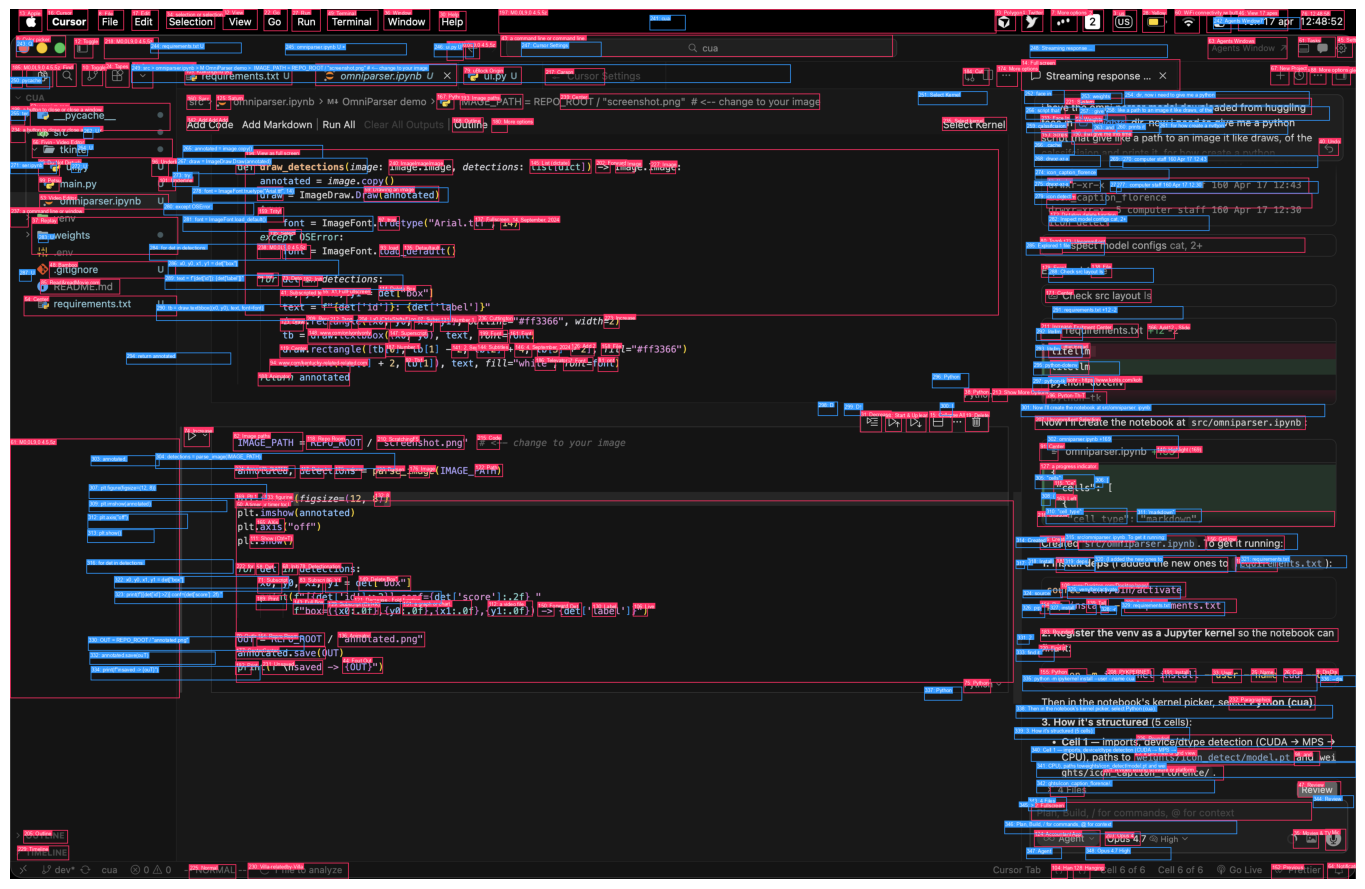

Icons detected : 241   |   OCR regions : 108

 ID  TYPE    CONF                BOX                 LABEL
───────────────────────────────────────────────────────────────────────────
  0  icon   0.748  (   15,   69,  143,  124)  Color picker
  1  icon   0.715  (  120,  141,  171,  199)  Find
  2  icon   0.712  ( 2755,    1, 2809,   58)  2
  3  icon   0.689  ( 2831,    2, 2894,   59)  us
  4  icon   0.670  ( 2597,    0, 2653,   59)  Twitter
  5  icon   0.666  (   43,  142,  110,  200)  Copy
  6  icon   0.626  ( 3377, 2105, 3431, 2160)  Mic
  7  icon   0.625  ( 2673,    0, 2741,   59)  More options
  8  icon   0.622  (  226,    3,  292,   55)  File
  9  icon   0.613  ( 3353, 1693, 3412, 1730)  DisDis
 10  icon   0.598  (  184,  141,  238,  198)  Toggle
 11  icon   0.586  ( 3072,    0, 3135,   62)  Show button
 12  icon   0.586  (  164,   74,  214,  127)  Toggle
 13  icon   0.579  (   22,    2,   83,   58)  Apple
 14  icon   0.577  ( 2596,  129, 3004,  210)  Full screen
 15  icon   0.554  (

In [12]:
# ── Tune these before running ──────────────────────────────────────────────
IMAGE_PATH     = REPO_ROOT / "screenshot.png"  # path to your screenshot

BBOX_THRESHOLD = 0.01    # YOLO confidence  (0–1)  lower → more boxes
IOU_THRESHOLD  = 0.01    # NMS IoU          (0–1)  lower → fewer overlapping boxes
IMGSZ          = 640    # YOLO input size  e.g. 1024; None = native resolution
USE_OCR        = True    # overlay EasyOCR text detections (blue boxes)
# ───────────────────────────────────────────────────────────────────────────

annotated, detections = parse_image(
    IMAGE_PATH,
    bbox_threshold=BBOX_THRESHOLD,
    iou_threshold=IOU_THRESHOLD,
    imgsz=IMGSZ,
    use_ocr=USE_OCR,
)

plt.figure(figsize=(14, 9))
plt.imshow(annotated)
plt.axis("off")
plt.tight_layout()
plt.show()

icons = [d for d in detections if d.get("type") == "icon"]
texts = [d for d in detections if d.get("type") == "text"]
print(f"Icons detected : {len(icons)}   |   OCR regions : {len(texts)}")
print()
print(f"{'ID':>3}  {'TYPE':^5}  {'CONF':>5}  {'BOX':^32}  LABEL")
print("─" * 75)
for det in detections:
    x0, y0, x1, y1 = det["box"]
    print(f"{det['id']:>3}  {det.get('type','?'):^5}  {det['score']:.3f}  "
          f"({x0:>5.0f},{y0:>5.0f},{x1:>5.0f},{y1:>5.0f})  {det['label']}")

out_path = REPO_ROOT / "annotated.png"
annotated.save(out_path)
print(f"\nsaved → {out_path}")